# Branching Process

A single amoeba, Bobo, lives in a pond. 

After one minute Bobo will either die, split into two amoebas, or stay the same, with equal
probability, and in subsequent minutes all living amoebas will behave the same way,
independently. 

What is the probability that the amoeba population will eventually
die out?

<img src = 'images/amoeba.png' width = 500>

----

## Solution:

Let $D$ be the event that the population eventually dies out; we want to find $P(D)$

Let $B_i$ be the event that Bobo turns into $i$ amoebas after the first minute, for $i = 0,1,2$

We know

$$
\begin{aligned}
P(D|B_0) &= 1 
\\
P(D|B_1) &= P(D)
\end{aligned}
$$

If Bobo splits into two, then we just have two independent versions of our original problem! 

We need both of the oﬀspring to eventually die out, so

$$
P(D|B_2) = P(D)^2
$$

and by law of total probability

$$
P(D) = P(D|B_0) P(B_0) + P(D|B_1) P(B_1) + P(D|B_2) P(B_2)
$$

Since whole $P(B_i)$'s are equal and $\frac{1}{3}$, we get

$$
P(D) = 1 \cdot \frac{1}{3} + P(D) \cdot \frac{1}{3} + P(D)^2 \cdot \frac{1}{3}
$$

If we let $P(D) = x$, then the equation looks like 

$$
\begin{aligned}
1 - 2x + x^2 &= 0 \\
(x-1)^2 &= 0 \\
x &= 1 \\
P(D) &= 1
\end{aligned}
$$

Thus we find out that the amoeba population will die out with probability 1.

------

## Simulation

In [102]:
import numpy as np
import pandas as pd
from plotnine import *

In [118]:
def oneStrip(minute = 10):
    n = 1
    time_series = [n]

    for _ in range(minute):
        decisions = np.random.randint(0,3, n)
        n = np.sum(decisions)
        time_series.append(int(n))
    
    return time_series

In [119]:
def experiments(springSize = 5, minute = 10):
    np.random.seed(25285)
    names = ['C' + str(i+1) for i in range(springSize)]

    df = pd.DataFrame([oneStrip(minute) for _ in range(springSize)])
    df['Spring'] = names

    cols = df.columns.tolist()
    df = df[[cols[-1]] + cols[:-1]]

    return df


In [120]:
minutes = 1000
springSize = 100

df = experiments(springSize, minutes)
df = df.melt(id_vars='Spring', var_name = 'Time', value_name= 'Size')
df.head()

,Spring,Time,Size
0,C1,0,1
1,C2,0,1
2,C3,0,1
3,C4,0,1
4,C5,0,1


In [121]:
def graphExperiment(springSize = 100, minutes = 100):
    df = experiments(springSize, minutes)
    df = df.melt(id_vars='Spring', var_name = 'Time', value_name= 'Size')
    df['Time'] = df['Time'].astype(int)

    minutes_scale = minutes // 20

    p = (
        ggplot(df, aes('Time', 'Size', group='Spring', color='Spring')) +
        geom_line(alpha=0.5) +
        scale_x_continuous(breaks=range(0, minutes+1, minutes_scale)) +
        labs(title=f"Sample size: {springSize}, Minutes: {minutes}") +
        theme(legend_position="none",
              axis_text_x=element_text(angle=90, size=10))
    )
    
    return p

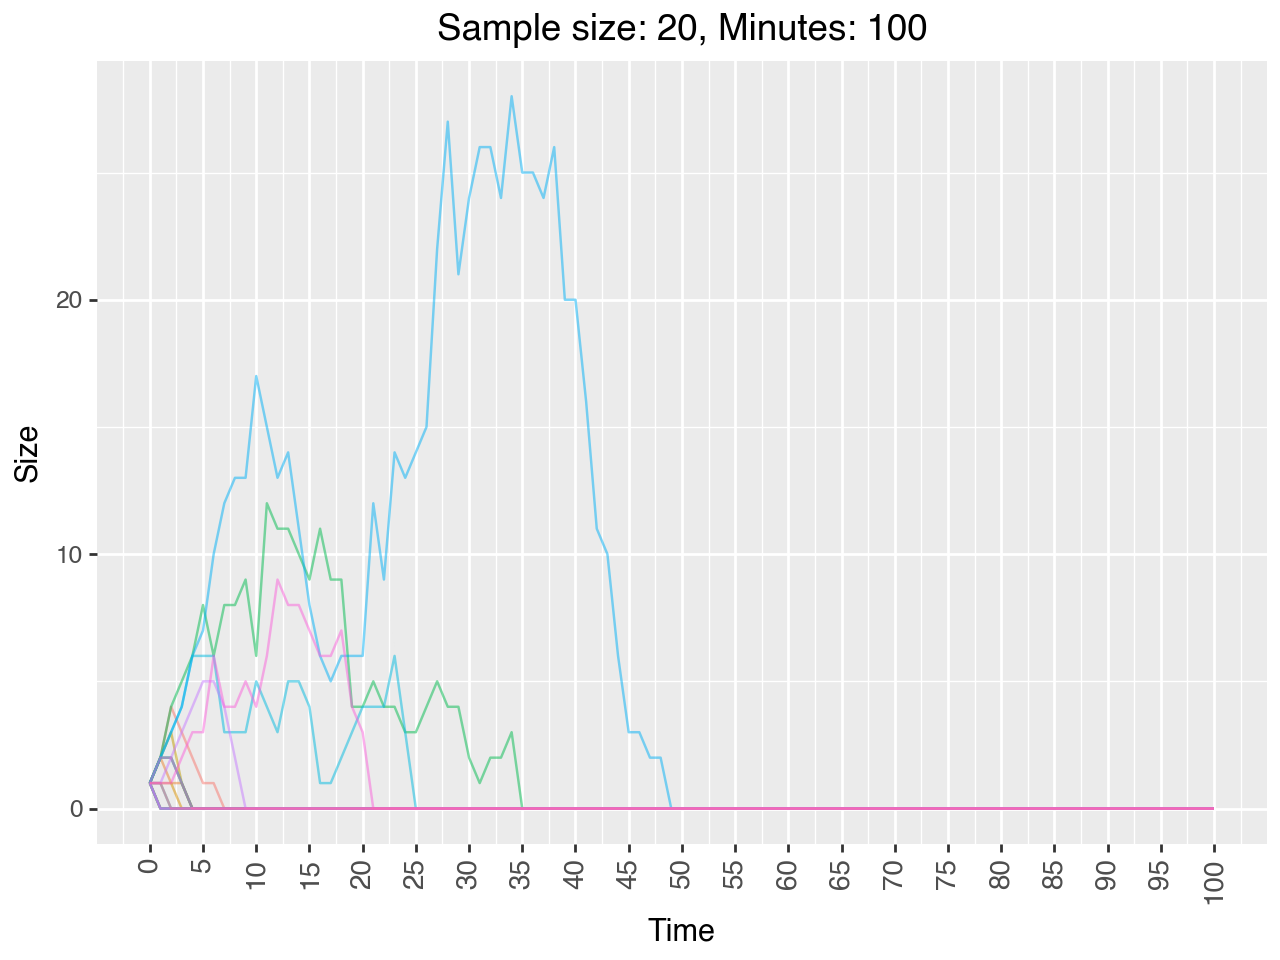

In [124]:
graphExperiment(20, 100)

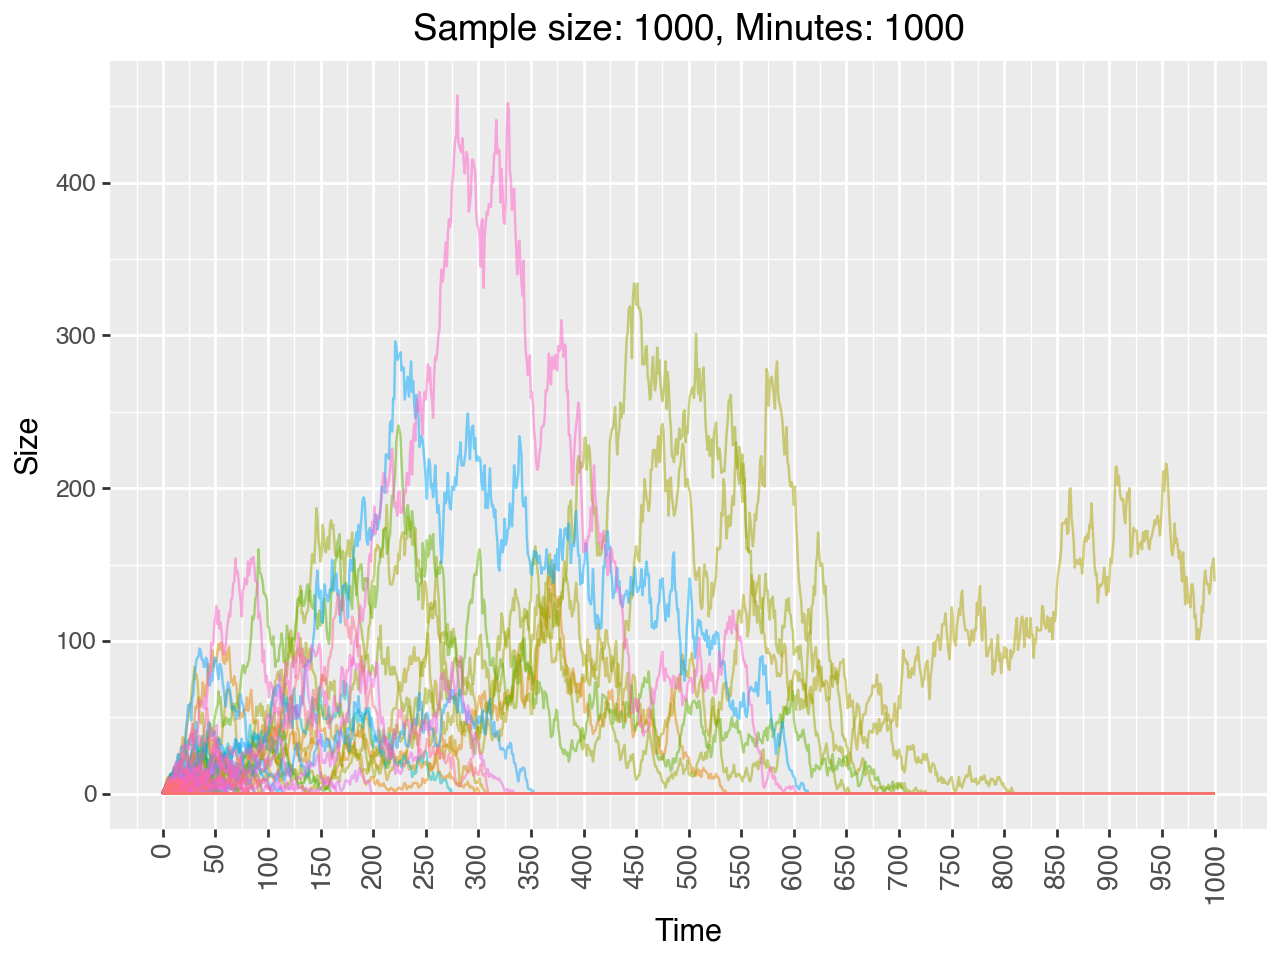

In [123]:
graphExperiment(1000, 1000)

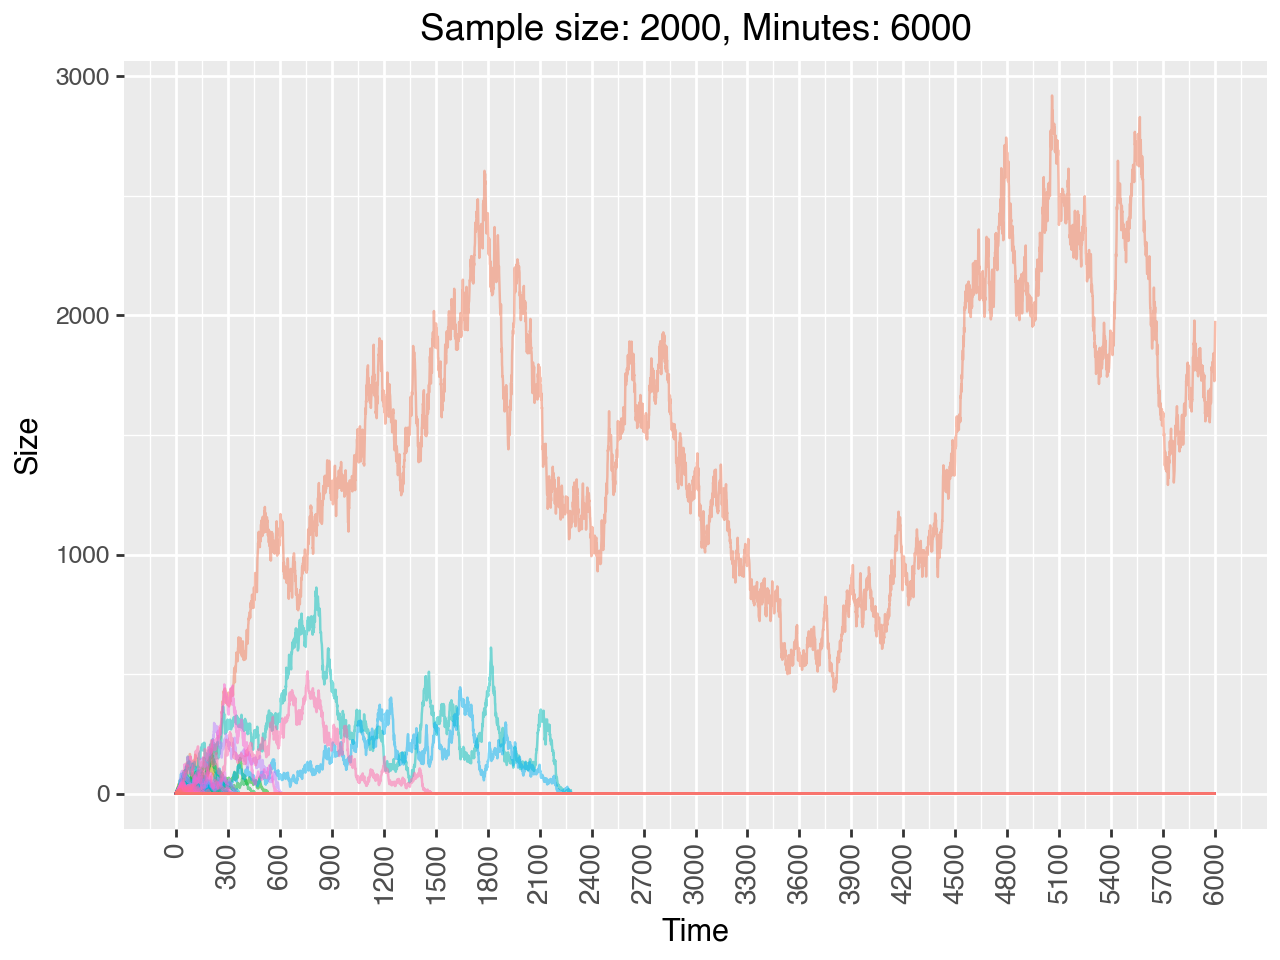

In [126]:
graphExperiment(2000, 6000)